# 01. 자치구 유형화 — 해석 가능한 K-means

## 분석 목적
- 쓰레기 발생량이 아닌 **도시 구조** 기준으로 자치구를 유형화
- K-means 클러스터링 → 군집 특성 해석 → 수동 라벨링
- 최종 라벨: **주거형 / 상업·업무형 / 유동인구형 / 혼합형**

## 기준 연도: 2023년
- 폐기물, 인구, 상권, 생활인구 모두 2023년 데이터 존재
- 택배 데이터는 2023년 8~12월 → 해당 기간 값 사용

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

BASE  = Path('../../data')
PROC  = BASE / 'processed'
OUT   = BASE / 'final'
OUT.mkdir(parents=True, exist_ok=True)

YEAR = 2023
print(f'기준 연도: {YEAR}')

기준 연도: 2023


## 1. 데이터 로드 및 병합

In [43]:
def load_year(path, year=YEAR, year_col='year'):
    df = pd.read_csv(path)
    return df[df[year_col] == year].copy()

# eda_master (day_night_ratio, biz_total, food_accom_biz 등 포함)
df_master = pd.read_csv(OUT / 'eda_master_v2_by_gu_year.csv', encoding='utf-8-sig')
df = df_master[df_master['year'] == YEAR][[
    'gu', 'total_pop', 'elderly_ratio',
    'living_pop_daily_avg', 'day_night_ratio',
    'biz_total', 'food_accom_biz'
]].copy()

# 종사자 수 (emp_total) — 사업체 파일에서 추가
df_biz = load_year(PROC / 'business' / 'business_by_industry_gu_year.csv')
df = df.merge(df_biz[['gu', 'emp_total']], on='gu', how='left')

print('병합 완료:', df.shape)
print('결측:\n', df.isnull().sum()[df.isnull().sum() > 0])
df.head(3)

병합 완료: (25, 8)
결측:
 Series([], dtype: int64)


,gu,total_pop,elderly_ratio,living_pop_daily_avg,day_night_ratio,biz_total,food_accom_biz,emp_total
0,강남구,550282,15.738476,1.954311e+07,1.356774,104299,4198,772567
1,강동구,463318,17.910809,1.195422e+07,0.904435,43358,6174,162732
2,강북구,292977,23.420610,6.668592e+06,0.894337,26310,3497,77797


## 2. 클러스터링 변수 생성 — "크기"가 아닌 "성격"

In [44]:
f = df.copy()

# ── 변수 파생 ──────────────────────────────────────────
f['log_total_pop']    = np.log(f['total_pop'])                        # 인구 규모 (로그 스케일)
f['elderly_ratio']    = f['elderly_ratio']                            # 고령인구 비율
f['living_pop_ratio'] = f['living_pop_daily_avg'] / f['total_pop']    # 생활인구 / 등록인구
f['day_night_ratio']  = f['day_night_ratio']                          # 주야간 인구비
f['biz_per_10k']      = f['biz_total'] / f['total_pop'] * 10000       # 만명당 사업체 수
f['emp_per_pop']      = f['emp_total'] / f['total_pop']               # 종사자 / 등록인구
f['food_accom_ratio'] = f['food_accom_biz'] / f['biz_total']          # 음식숙박업 비중

CLUSTER_VARS = [
    'log_total_pop',
    'elderly_ratio',
    'living_pop_ratio',
    'day_night_ratio',
    'biz_per_10k',
    'emp_per_pop',
    'food_accom_ratio',
]

X = f.set_index('gu')[CLUSTER_VARS].copy()
print('클러스터링 변수:', CLUSTER_VARS)
print('Shape:', X.shape)
print('결측:\n', X.isnull().sum())

클러스터링 변수: ['log_total_pop', 'elderly_ratio', 'living_pop_ratio', 'day_night_ratio', 'biz_per_10k', 'emp_per_pop', 'food_accom_ratio']
Shape: (25, 7)
결측:
 log_total_pop       0
elderly_ratio       0
living_pop_ratio    0
day_night_ratio     0
biz_per_10k         0
emp_per_pop         0
food_accom_ratio    0
dtype: int64


In [45]:
# 결측 처리 (중앙값 대체)
X = X.fillna(X.median())

# 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

print('표준화 완료')
X_scaled.describe().round(2)

표준화 완료


,log_total_pop,elderly_ratio,living_pop_ratio,day_night_ratio,biz_per_10k,emp_per_pop,food_accom_ratio
count,25.00,25.00,25.00,25.00,25.00,25.00,25.00
mean,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00
std,1.02,1.02,1.02,1.02,1.02,1.02,1.02
min,-2.69,-1.50,-0.97,-0.88,-0.74,-0.73,-1.62
25%,-0.42,-0.60,-0.64,-0.68,-0.56,-0.64,-0.75
50%,0.19,-0.12,-0.51,-0.36,-0.36,-0.46,0.04
75%,0.65,0.45,0.27,0.22,0.10,0.09,0.53
max,1.60,2.67,3.08,3.38,4.00,3.82,2.32


## 3. 최적 군집 수 결정 — Elbow + Silhouette

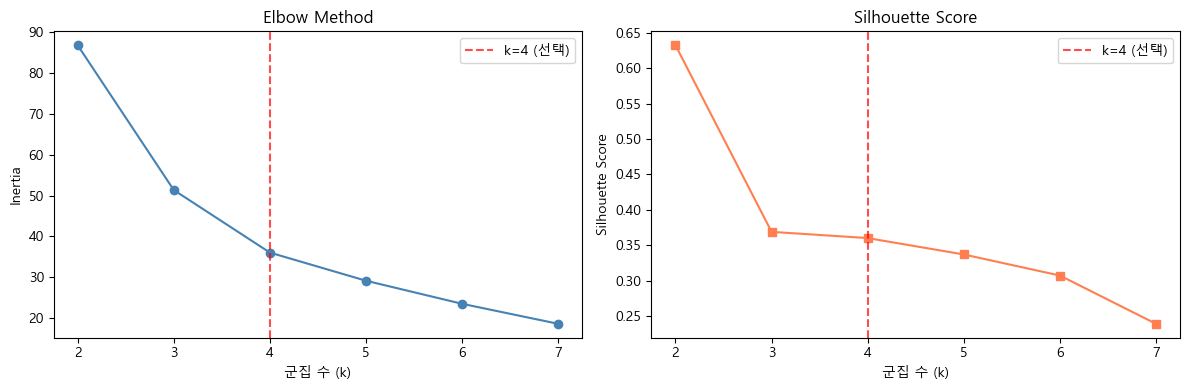

k별 Silhouette:
  k=2: 0.6328  ← Silhouette 최적
  k=3: 0.3688  
  k=4: 0.3600  
  k=5: 0.3369  
  k=6: 0.3071  
  k=7: 0.2388  

[k=4 선택 근거]
  - 표본이 25개(자치구)로 적어 Silhouette이 k=2에서 높게 나오는 경향이 있음
  - 2분할은 정보량이 부족하여 도시 구조 설명에 한계
  - 4분할(주거형/상업·업무형/유동인구형/혼합형)이 정책 해석에 가장 실용적
  - Silhouette은 참고 지표, 최종 판단은 군집 내용의 해석 가능성 우선


In [46]:
inertias = []
silhouettes = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertias, 'o-', color='steelblue')
axes[0].set_xlabel('군집 수 (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].axvline(4, color='red', linestyle='--', alpha=0.7, label='k=4 (선택)')
axes[0].legend()

axes[1].plot(list(K_range), silhouettes, 's-', color='coral')
axes[1].set_xlabel('군집 수 (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].axvline(4, color='red', linestyle='--', alpha=0.7, label='k=4 (선택)')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT / 'elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = list(K_range)[silhouettes.index(max(silhouettes))]
print('k별 Silhouette:')
for k, s in zip(K_range, silhouettes):
    mark = '← Silhouette 최적' if k == best_k else ''
    print(f'  k={k}: {s:.4f}  {mark}')

print()
print('[k=4 선택 근거]')
print('  - 표본이 25개(자치구)로 적어 Silhouette이 k=2에서 높게 나오는 경향이 있음')
print('  - 2분할은 정보량이 부족하여 도시 구조 설명에 한계')
print('  - 4분할(주거형/상업·업무형/유동인구형/혼합형)이 정책 해석에 가장 실용적')
print('  - Silhouette은 참고 지표, 최종 판단은 군집 내용의 해석 가능성 우선')

## 4. K-means 클러스터링 (k=4)

In [47]:
K = 4
km_final = KMeans(n_clusters=K, random_state=42, n_init=100)
f['cluster'] = km_final.fit_predict(X_scaled)

print('군집별 자치구:')
for c in range(K):
    gus = f[f['cluster'] == c]['gu'].tolist()
    print(f'  Cluster {c} ({len(gus)}개): {gus}')

군집별 자치구:
  Cluster 0 (3개): ['강북구', '도봉구', '중랑구']
  Cluster 1 (13개): ['강동구', '강서구', '관악구', '광진구', '구로구', '노원구', '동대문구', '동작구', '서대문구', '성북구', '송파구', '양천구', '은평구']
  Cluster 2 (2개): ['종로구', '중구']
  Cluster 3 (7개): ['강남구', '금천구', '마포구', '서초구', '성동구', '영등포구', '용산구']


## 5. 군집 특성 분석 — 라벨링 근거

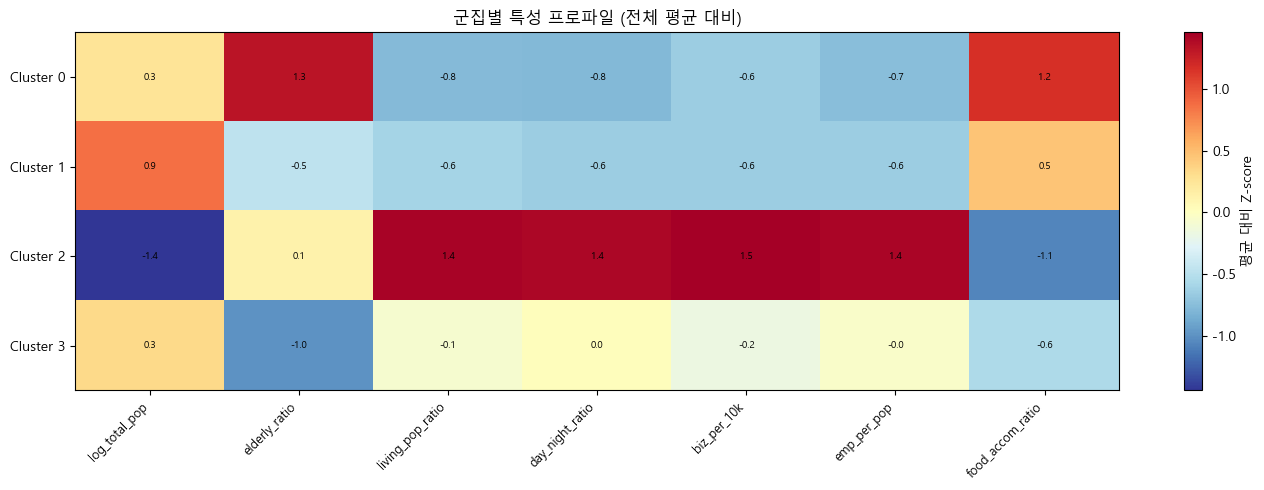


군집별 핵심 지표 (원값):
         log_total_pop  elderly_ratio  day_night_ratio  biz_per_10k  \
cluster                                                               
0              12.6993        22.1854           0.8876     927.2501   
1              13.0031        18.0457           0.9375     928.7069   
2              11.8552        19.3927           1.7023    4110.7136   
3              12.7374        16.8217           1.1884    1661.6939   

         food_accom_ratio  
cluster                    
0                  0.1697  
1                  0.1273  
2                  0.0377  
3                  0.0676  


In [48]:
# 군집별 변수 평균 (표준화 전 원값)
cluster_profile = f.groupby('cluster')[CLUSTER_VARS].mean()

# 전체 평균 대비 z-score로 표현
cluster_z = (cluster_profile - cluster_profile.mean()) / cluster_profile.std()

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(cluster_z.values, aspect='auto', cmap='RdYlBu_r')
plt.colorbar(im, ax=ax, label='평균 대비 Z-score')

ax.set_xticks(range(len(CLUSTER_VARS)))
ax.set_xticklabels(CLUSTER_VARS, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(K))
ax.set_yticklabels([f'Cluster {i}' for i in range(K)])
ax.set_title('군집별 특성 프로파일 (전체 평균 대비)')

for i in range(K):
    for j in range(len(CLUSTER_VARS)):
        ax.text(j, i, f'{cluster_z.values[i,j]:.1f}', ha='center', va='center', fontsize=7)

plt.tight_layout()
plt.savefig(OUT / 'cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n군집별 핵심 지표 (원값):')
display_cols = ['log_total_pop', 'elderly_ratio', 'day_night_ratio', 'biz_per_10k', 'food_accom_ratio']
print(cluster_profile[display_cols].round(4))

In [49]:
for c in range(K):
    sub = f[f['cluster'] == c].set_index('gu')
    print(f'\n── Cluster {c} ({len(sub)}개 구) ──')
    print('  구:', sub.index.tolist())
    print('  log(인구)    :', sub['log_total_pop'].mean().round(3))
    print('  고령인구비율 :', sub['elderly_ratio'].mean().round(2))
    print('  생활인구비율 :', sub['living_pop_ratio'].mean().round(3))
    print('  주야간인구비 :', sub['day_night_ratio'].mean().round(3))
    print('  만명당사업체 :', sub['biz_per_10k'].mean().round(1))
    print('  종사자/인구  :', sub['emp_per_pop'].mean().round(3))
    print('  음식숙박비중 :', sub['food_accom_ratio'].mean().round(3))


── Cluster 0 (3개 구) ──
  구: ['강북구', '도봉구', '중랑구']
  log(인구)    : 12.699
  고령인구비율 : 22.19
  생활인구비율 : 21.378
  주야간인구비 : 0.888
  만명당사업체 : 927.3
  종사자/인구  : 0.272
  음식숙박비중 : 0.17

── Cluster 1 (13개 구) ──
  구: ['강동구', '강서구', '관악구', '광진구', '구로구', '노원구', '동대문구', '동작구', '서대문구', '성북구', '송파구', '양천구', '은평구']
  log(인구)    : 13.003
  고령인구비율 : 18.05
  생활인구비율 : 23.345
  주야간인구비 : 0.938
  만명당사업체 : 928.7
  종사자/인구  : 0.371
  음식숙박비중 : 0.127

── Cluster 2 (2개 구) ──
  구: ['종로구', '중구']
  log(인구)    : 11.855
  고령인구비율 : 19.39
  생활인구비율 : 46.353
  주야간인구비 : 1.702
  만명당사업체 : 4110.7
  종사자/인구  : 2.489
  음식숙박비중 : 0.038

── Cluster 3 (7개 구) ──
  구: ['강남구', '금천구', '마포구', '서초구', '성동구', '영등포구', '용산구']
  log(인구)    : 12.737
  고령인구비율 : 16.82
  생활인구비율 : 29.278
  주야간인구비 : 1.188
  만명당사업체 : 1661.7
  종사자/인구  : 0.989
  음식숙박비중 : 0.068


## 6. 군집 라벨링

아래 결과를 보고 각 군집에 라벨을 붙인다.
- **주거형**: 인구밀도 높음, 직장인구 비율 낮음, 고령화율 높음
- **상업·업무형**: 직장인구 비율 높음, 사업체 밀도 높음, 매출 높음
- **유동인구형**: 직장인구/주민 비율 높음, 음식숙박 비중 높음
- **혼합형**: 여러 특성이 중간값 수준

In [50]:
# ── 축별 군집 점수 계산 ─────────────────────────────────
axis_scores = {
    '주거형':      cluster_z[['log_total_pop', 'elderly_ratio']].mean(axis=1),
    '상업·업무형': cluster_z[['biz_per_10k', 'emp_per_pop']].mean(axis=1),
    '고령·생활상권형':  cluster_z[['living_pop_ratio', 'day_night_ratio', 'food_accom_ratio']].mean(axis=1),
    '혼합형':      cluster_z[CLUSTER_VARS].abs().mean(axis=1) * -1,  # 평균으로부터 가장 가까운 군집
}
axis_df = pd.DataFrame(axis_scores)
print('축별 군집 점수 (클수록 해당 성격이 강함):')
print(axis_df.round(2))

# ── 1:1 그리디 배정 (중복 라벨 방지) ─────────────────────
LABEL_PRIORITY = ['상업·업무형', '고령·생활상권형', '주거형', '혼합형']
auto_labels = {}
assigned_clusters = set()

for label in LABEL_PRIORITY:
    candidates = axis_df[label].drop(list(assigned_clusters))
    if candidates.empty:
        break
    best_cluster = candidates.idxmax()
    auto_labels[best_cluster] = label
    assigned_clusters.add(best_cluster)

for c in range(K):
    if c not in auto_labels:
        auto_labels[c] = '혼합형'

print('\n자동 라벨링 결과 (1:1 배정):')
for c in range(K):
    gus = f[f['cluster'] == c]['gu'].tolist()
    print(f'  Cluster {c} → {auto_labels[c]}: {gus}')

LABEL_MAP = {}
print('\n(LABEL_MAP이 비어 있으면 자동 배정 사용)')

축별 군집 점수 (클수록 해당 성격이 강함):
          주거형  상업·업무형  고령·생활상권형   혼합형
cluster                              
0        0.79   -0.70     -0.13 -0.81
1        0.20   -0.65     -0.26 -0.62
2       -0.66    1.44      0.59 -1.19
3       -0.33   -0.10     -0.20 -0.31

자동 라벨링 결과 (1:1 배정):
  Cluster 0 → 고령·생활상권형: ['강북구', '도봉구', '중랑구']
  Cluster 1 → 주거형: ['강동구', '강서구', '관악구', '광진구', '구로구', '노원구', '동대문구', '동작구', '서대문구', '성북구', '송파구', '양천구', '은평구']
  Cluster 2 → 상업·업무형: ['종로구', '중구']
  Cluster 3 → 혼합형: ['강남구', '금천구', '마포구', '서초구', '성동구', '영등포구', '용산구']

(LABEL_MAP이 비어 있으면 자동 배정 사용)


In [51]:
# LABEL_MAP이 비어있으면 자동 추정값 사용
if not LABEL_MAP:
    LABEL_MAP = auto_labels

f['gu_type'] = f['cluster'].map(LABEL_MAP)

# 유형별 최종 자치구 목록
type_order = ['주거형','상업·업무형','고령·생활상권형','물류·혼합형','혼합형']
for t in type_order:
    gus = f[f['gu_type'] == t]['gu'].tolist()
    if gus:
        print(f'{t} ({len(gus)}): {gus}')

주거형 (13): ['강동구', '강서구', '관악구', '광진구', '구로구', '노원구', '동대문구', '동작구', '서대문구', '성북구', '송파구', '양천구', '은평구']
상업·업무형 (2): ['종로구', '중구']
고령·생활상권형 (3): ['강북구', '도봉구', '중랑구']
혼합형 (7): ['강남구', '금천구', '마포구', '서초구', '성동구', '영등포구', '용산구']


## 7. PCA 2D 시각화

PC1 설명 분산: 70.3%
PC2 설명 분산: 19.8%


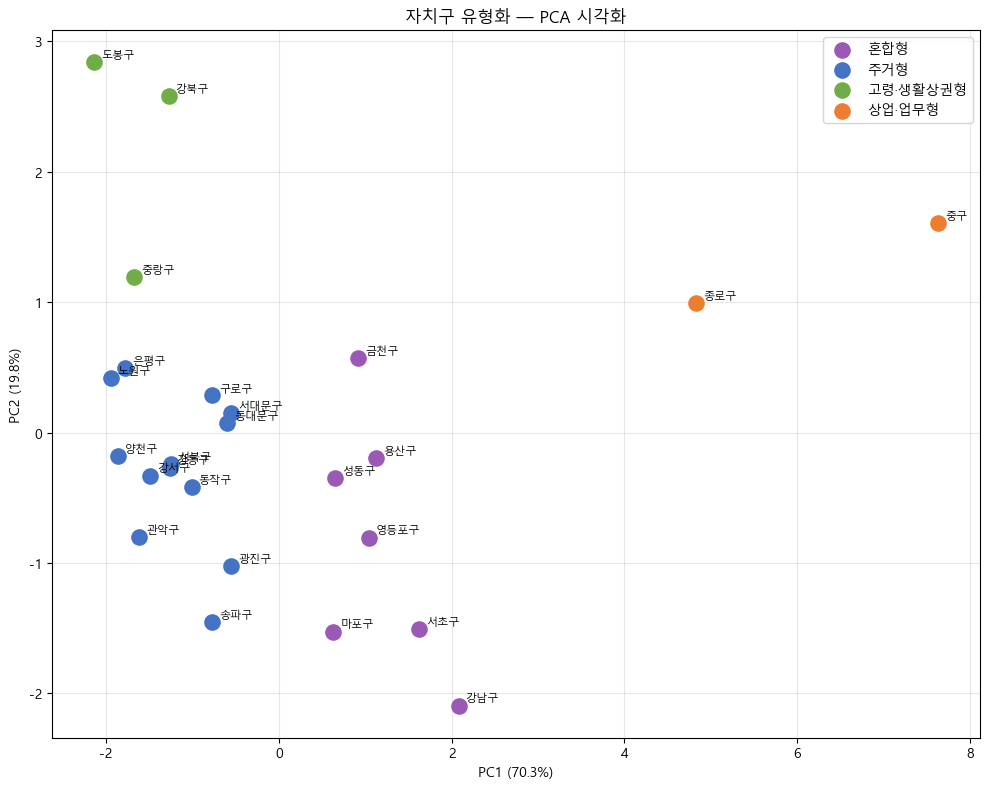

In [52]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

print(f'PC1 설명 분산: {pca.explained_variance_ratio_[0]:.1%}')
print(f'PC2 설명 분산: {pca.explained_variance_ratio_[1]:.1%}')

COLORS = {'주거형':'#4472C4','상업·업무형':'#ED7D31','고령·생활상권형':'#70AD47','물류·혼합형':'#FFC000','혼합형':'#9B59B6'}

fig, ax = plt.subplots(figsize=(10, 8))
for t in f['gu_type'].unique():
    mask = f['gu_type'] == t
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=COLORS.get(t, 'gray'), s=120, label=t, zorder=3)

for i, gu in enumerate(X_scaled.index):
    ax.annotate(gu, (coords[i, 0], coords[i, 1]),
                textcoords='offset points', xytext=(5, 3), fontsize=8)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('자치구 유형화 — PCA 시각화')
ax.legend(loc='best')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / 'cluster_pca.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. 레이더 차트 — 유형별 특성 프로파일

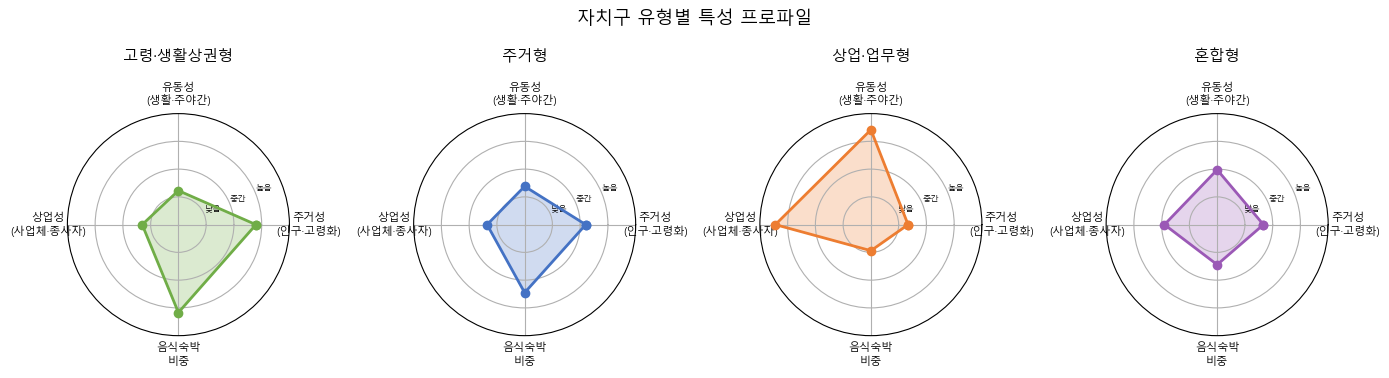

In [53]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe

# 축 4개
AXES = ['주거성\n(인구·고령화)', '유동성\n(생활·주야간)', '상업성\n(사업체·종사자)', '음식숙박\n비중']
AXIS_COLS = [
    ['log_total_pop', 'elderly_ratio'],
    ['living_pop_ratio', 'day_night_ratio'],
    ['biz_per_10k', 'emp_per_pop'],
    ['food_accom_ratio'],
]

# 군집별 각 축 평균 z-score
radar_data = {}
for i, cols in enumerate(AXIS_COLS):
    radar_data[AXES[i]] = cluster_z[cols].mean(axis=1)
radar_df = pd.DataFrame(radar_data)
radar_df.index = [LABEL_MAP.get(i, f'C{i}') for i in radar_df.index]

# 레이더 차트
n_axes = len(AXES)
angles = [2 * np.pi * i / n_axes for i in range(n_axes)]
angles += angles[:1]

fig, axes = plt.subplots(1, len(radar_df), figsize=(14, 3.5),
                          subplot_kw=dict(polar=True))
if len(radar_df) == 1:
    axes = [axes]

for ax, (label, row) in zip(axes, radar_df.iterrows()):
    vals = (row.values + 2) / 4
    vals = np.clip(vals, 0, 1)
    vals = np.append(vals, vals[0])

    color = list(COLORS.values())[list(COLORS.keys()).index(label) if label in COLORS else 0]
    ax.plot(angles, vals, 'o-', linewidth=2, color=color)
    ax.fill(angles, vals, alpha=0.25, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(AXES, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['낮음', '중간', '높음'], fontsize=6)
    ax.set_title(label, fontsize=11, pad=15)

plt.suptitle('자치구 유형별 특성 프로파일', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUT / 'cluster_radar.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. 결과 저장

In [54]:
# 클러스터링 결과 저장
result_cols = ['gu', 'cluster', 'gu_type'] + CLUSTER_VARS
df_result = f[result_cols].sort_values('cluster').reset_index(drop=True)
df_result.to_csv(OUT / 'gu_cluster_result.csv', index=False, encoding='utf-8-sig')
print('저장:', df_result.shape)

# 군집 특성 프로파일 저장
profile_out = cluster_profile.copy()
profile_out.index = [LABEL_MAP.get(i, f'C{i}') for i in profile_out.index]
profile_out.to_csv(OUT / 'gu_cluster_profile.csv', encoding='utf-8-sig')

print('\n── 최종 유형화 결과 ──')
for _, row in df_result[['gu', 'gu_type']].iterrows():
    print(f'  {row["gu"]:6s} → {row["gu_type"]}')

저장: (25, 10)

── 최종 유형화 결과 ──
  강북구    → 고령·생활상권형
  도봉구    → 고령·생활상권형
  중랑구    → 고령·생활상권형
  강서구    → 주거형
  구로구    → 주거형
  광진구    → 주거형
  노원구    → 주거형
  강동구    → 주거형
  서대문구   → 주거형
  동작구    → 주거형
  동대문구   → 주거형
  은평구    → 주거형
  송파구    → 주거형
  양천구    → 주거형
  성북구    → 주거형
  관악구    → 주거형
  종로구    → 상업·업무형
  중구     → 상업·업무형
  성동구    → 혼합형
  금천구    → 혼합형
  강남구    → 혼합형
  서초구    → 혼합형
  마포구    → 혼합형
  영등포구   → 혼합형
  용산구    → 혼합형


In [55]:
# 유형별 요약 통계
summary = df_result.groupby('gu_type')[CLUSTER_VARS].mean().round(4)
print('유형별 평균 특성값:')
summary

유형별 평균 특성값:


,log_total_pop,elderly_ratio,living_pop_ratio,day_night_ratio,biz_per_10k,emp_per_pop,food_accom_ratio
gu_type,,,,,,,
고령·생활상권형,12.6993,22.1854,21.3781,0.8876,927.2501,0.2719,0.1697
상업·업무형,11.8552,19.3927,46.3532,1.7023,4110.7136,2.4892,0.0377
주거형,13.0031,18.0457,23.3448,0.9375,928.7069,0.3708,0.1273
혼합형,12.7374,16.8217,29.2781,1.1884,1661.6939,0.9891,0.0676


## 10. 주거형 세분화 — 2단계 클러스터링

1차 K-means 결과에서 `주거형`으로 분류된 자치구가 많기 때문에,  
주거형 자치구만 따로 추출해 `k=2`로 한 번 더 군집화한다.

- 1차 유형: 상업·업무형 / 고령·생활상권형 / 주거형 / 혼합형
- 2차 유형: 주거형 내부를 **주거 중심형 / 생활권 주거형**으로 세분화


In [56]:
# ─────────────────────────────────────────────────────────
# 10-1. 주거형 자치구만 추출
# ─────────────────────────────────────────────────────────

# f에는 앞 단계에서 gu_type이 생성되어 있어야 함
if 'gu_type' not in f.columns:
    raise ValueError("먼저 1차 클러스터링 라벨링 셀을 실행해서 f['gu_type']을 만들어주세요.")

# households가 f에 없으면 df_master에서 추가
if 'households' not in f.columns:
    if 'df_master' in globals() and 'households' in df_master.columns:
        hh = df_master[df_master['year'] == YEAR][['gu', 'households']].copy()
        f = f.merge(hh, on='gu', how='left')
        print("households 컬럼을 df_master에서 추가했습니다.")
    else:
        print("주의: households 컬럼이 없어 avg_hh_size는 제외합니다.")

# 주거형 세분화용 파생변수
if 'households' in f.columns:
    f['avg_hh_size'] = f['total_pop'] / f['households']
    f['log_households'] = np.log(f['households'])

# 주거형만 추출
res = f[f['gu_type'] == '주거형'].copy()

print("주거형 자치구 수:", len(res))
print(res['gu'].tolist())

if len(res) < 4:
    raise ValueError("주거형 자치구가 너무 적어 2단계 클러스터링을 수행하기 어렵습니다.")


households 컬럼을 df_master에서 추가했습니다.
주거형 자치구 수: 13
['강동구', '강서구', '관악구', '광진구', '구로구', '노원구', '동대문구', '동작구', '서대문구', '성북구', '송파구', '양천구', '은평구']


In [57]:
# ─────────────────────────────────────────────────────────
# 10-2. 주거형 내부 k=2 클러스터링
# ─────────────────────────────────────────────────────────

# 기본 변수 + 가구 관련 변수
RES_CLUSTER_VARS = [
    'log_total_pop',
    'elderly_ratio',
    'living_pop_ratio',
    'day_night_ratio',
    'biz_per_10k',
    'emp_per_pop',
    'food_accom_ratio'
]

# households가 있으면 주거 세분화에 유용한 변수 추가
if 'avg_hh_size' in f.columns:
    RES_CLUSTER_VARS += ['avg_hh_size', 'log_households']

# 실제 존재하는 변수만 사용
RES_CLUSTER_VARS = [c for c in RES_CLUSTER_VARS if c in res.columns]

X_res = res.set_index('gu')[RES_CLUSTER_VARS].copy()
X_res = X_res.fillna(X_res.median())

res_scaler = StandardScaler()
X_res_scaled = res_scaler.fit_transform(X_res)
X_res_scaled = pd.DataFrame(X_res_scaled, index=X_res.index, columns=X_res.columns)

# k=2
K_RES = 2
km_res = KMeans(n_clusters=K_RES, random_state=42, n_init=100)
res['res_cluster'] = km_res.fit_predict(X_res_scaled)

# 실루엣 점수
res_silhouette = silhouette_score(X_res_scaled, res['res_cluster'])
print(f"주거형 내부 k=2 silhouette score: {res_silhouette:.3f}")

print("\n주거형 내부 군집 결과:")
for c in sorted(res['res_cluster'].unique()):
    gus = res[res['res_cluster'] == c]['gu'].tolist()
    print(f"  Residential Cluster {c} ({len(gus)}개): {gus}")


주거형 내부 k=2 silhouette score: 0.185

주거형 내부 군집 결과:
  Residential Cluster 0 (6개): ['강서구', '광진구', '구로구', '동대문구', '서대문구', '송파구']
  Residential Cluster 1 (7개): ['강동구', '관악구', '노원구', '동작구', '성북구', '양천구', '은평구']


In [58]:
# ─────────────────────────────────────────────────────────
# 10-3. 주거형 하위군집 프로파일 확인 및 자동 라벨링
# ─────────────────────────────────────────────────────────

# 원값 기준 평균
res_profile = res.groupby('res_cluster')[RES_CLUSTER_VARS].mean()

print("주거형 하위군집 평균 특성값:")
display(res_profile.round(4))

# 해석용 핵심 변수만 따로 보기
res_display_cols = [
    c for c in [
        'log_total_pop', 'log_households', 'elderly_ratio',
        'living_pop_ratio', 'day_night_ratio',
        'biz_per_10k', 'emp_per_pop', 'food_accom_ratio', 'avg_hh_size'
    ] if c in res_profile.columns
]

print("\n해석용 핵심 지표:")
display(res_profile[res_display_cols].round(4))

# 라벨링 기준:
# - log_total_pop 또는 log_households가 더 큰 군집 → 주거 중심형
# - 나머지 → 생활권 주거형
if 'log_households' in res_profile.columns:
    size_score = res_profile[['log_total_pop', 'log_households']].mean(axis=1)
else:
    size_score = res_profile['log_total_pop']

large_cluster = size_score.idxmax()

RES_LABEL_MAP = {}
for c in res_profile.index:
    if c == large_cluster:
        RES_LABEL_MAP[c] = '주거 중심형'
    else:
        RES_LABEL_MAP[c] = '생활권 주거형'

print("\n주거형 하위군집 라벨:")
for c, label in RES_LABEL_MAP.items():
    gus = res[res['res_cluster'] == c]['gu'].tolist()
    print(f"  Residential Cluster {c} → {label}: {gus}")

res['res_type'] = res['res_cluster'].map(RES_LABEL_MAP)

# f에 최종 5유형 반영
f['gu_type_final'] = f['gu_type']

res_type_map = res.set_index('gu')['res_type']
f.loc[f['gu'].isin(res_type_map.index), 'gu_type_final'] = f.loc[
    f['gu'].isin(res_type_map.index), 'gu'
].map(res_type_map)

print("\n── 최종 5유형 결과 ──")
final_type_order = ['상업·업무형', '고령·생활상권형', '주거 중심형', '생활권 주거형', '혼합형', '물류·혼합형']
for t in final_type_order:
    gus = f[f['gu_type_final'] == t]['gu'].tolist()
    if gus:
        print(f"{t} ({len(gus)}): {gus}")


주거형 하위군집 평균 특성값:


,log_total_pop,elderly_ratio,living_pop_ratio,day_night_ratio,biz_per_10k,emp_per_pop,food_accom_ratio,avg_hh_size,log_households
res_cluster,,,,,,,,,
0,12.9716,17.770,24.2761,0.9890,1077.3579,0.4781,0.1190,2.1621,12.2015
1,13.0302,18.282,22.5466,0.8934,801.2918,0.2789,0.1345,2.1799,12.2555



해석용 핵심 지표:


,log_total_pop,log_households,elderly_ratio,living_pop_ratio,day_night_ratio,biz_per_10k,emp_per_pop,food_accom_ratio,avg_hh_size
res_cluster,,,,,,,,,
0,12.9716,12.2015,17.770,24.2761,0.9890,1077.3579,0.4781,0.1190,2.1621
1,13.0302,12.2555,18.282,22.5466,0.8934,801.2918,0.2789,0.1345,2.1799



주거형 하위군집 라벨:
  Residential Cluster 0 → 생활권 주거형: ['강서구', '광진구', '구로구', '동대문구', '서대문구', '송파구']
  Residential Cluster 1 → 주거 중심형: ['강동구', '관악구', '노원구', '동작구', '성북구', '양천구', '은평구']

── 최종 5유형 결과 ──
상업·업무형 (2): ['종로구', '중구']
고령·생활상권형 (3): ['강북구', '도봉구', '중랑구']
주거 중심형 (7): ['강동구', '관악구', '노원구', '동작구', '성북구', '양천구', '은평구']
생활권 주거형 (6): ['강서구', '광진구', '구로구', '동대문구', '서대문구', '송파구']
혼합형 (7): ['강남구', '금천구', '마포구', '서초구', '성동구', '영등포구', '용산구']


In [59]:
# ─────────────────────────────────────────────────────────
# 10-3. 주거형 하위군집 프로파일 확인 및 자동 라벨링
# ─────────────────────────────────────────────────────────

# 원값 기준 평균
res_profile = res.groupby('res_cluster')[RES_CLUSTER_VARS].mean()

print("주거형 하위군집 평균 특성값:")
display(res_profile.round(4))

# 해석용 핵심 변수만 따로 보기
res_display_cols = [
    c for c in [
        'log_total_pop', 'log_households', 'elderly_ratio',
        'living_pop_ratio', 'day_night_ratio',
        'biz_per_10k', 'emp_per_pop', 'food_accom_ratio', 'avg_hh_size'
    ] if c in res_profile.columns
]

print("\n해석용 핵심 지표:")
display(res_profile[res_display_cols].round(4))

# ---------------------------------------------------------
# 라벨링 기준
# - 규모(log_total_pop, log_households)가 더 큰 군집 → 주거 중심형
# - 나머지 → 생활권 주거형
# ---------------------------------------------------------
size_cols = [c for c in ['log_total_pop', 'log_households'] if c in res_profile.columns]

if len(size_cols) > 0:
    size_score = res_profile[size_cols].mean(axis=1)
else:
    raise ValueError("log_total_pop 또는 log_households 중 최소 1개는 있어야 합니다.")

large_cluster = size_score.idxmax()

RES_LABEL_MAP = {}
for c in res_profile.index:
    if c == large_cluster:
        RES_LABEL_MAP[c] = '주거 중심형'
    else:
        RES_LABEL_MAP[c] = '생활권 주거형'

print("\n주거형 하위군집 라벨:")
for c, label in RES_LABEL_MAP.items():
    gus = res.loc[res['res_cluster'] == c, 'gu'].tolist()
    print(f"  Residential Cluster {c} → {label}: {gus}")

# res에 반영
res = res.copy()
res['res_type'] = res['res_cluster'].map(RES_LABEL_MAP)

# ---------------------------------------------------------
# f에 최종 유형 반영
# ---------------------------------------------------------
f = f.copy()
f['gu_type_final'] = f['gu_type']

res_type_map = res.set_index('gu')['res_type']
mask_res = f['gu'].isin(res_type_map.index)
f.loc[mask_res, 'gu_type_final'] = f.loc[mask_res, 'gu'].map(res_type_map)

# ---------------------------------------------------------
# 최종 유형 출력 순서
# ※ 실제 데이터에 존재하는 유형만 출력
# ---------------------------------------------------------
candidate_type_order = [
    '상업·업무형',
    '고령·생활상권형',
    '주거 중심형',
    '생활권 주거형',
    '혼합형',
    '물류·혼합형'
]

final_type_order = [t for t in candidate_type_order if t in f['gu_type_final'].unique()]

print("\n── 최종 유형 결과 ──")
for t in final_type_order:
    gus = sorted(f.loc[f['gu_type_final'] == t, 'gu'].tolist())
    print(f"{t} ({len(gus)}): {gus}")

주거형 하위군집 평균 특성값:


,log_total_pop,elderly_ratio,living_pop_ratio,day_night_ratio,biz_per_10k,emp_per_pop,food_accom_ratio,avg_hh_size,log_households
res_cluster,,,,,,,,,
0,12.9716,17.770,24.2761,0.9890,1077.3579,0.4781,0.1190,2.1621,12.2015
1,13.0302,18.282,22.5466,0.8934,801.2918,0.2789,0.1345,2.1799,12.2555



해석용 핵심 지표:


,log_total_pop,log_households,elderly_ratio,living_pop_ratio,day_night_ratio,biz_per_10k,emp_per_pop,food_accom_ratio,avg_hh_size
res_cluster,,,,,,,,,
0,12.9716,12.2015,17.770,24.2761,0.9890,1077.3579,0.4781,0.1190,2.1621
1,13.0302,12.2555,18.282,22.5466,0.8934,801.2918,0.2789,0.1345,2.1799



주거형 하위군집 라벨:
  Residential Cluster 0 → 생활권 주거형: ['강서구', '광진구', '구로구', '동대문구', '서대문구', '송파구']
  Residential Cluster 1 → 주거 중심형: ['강동구', '관악구', '노원구', '동작구', '성북구', '양천구', '은평구']

── 최종 유형 결과 ──
상업·업무형 (2): ['종로구', '중구']
고령·생활상권형 (3): ['강북구', '도봉구', '중랑구']
주거 중심형 (7): ['강동구', '관악구', '노원구', '동작구', '성북구', '양천구', '은평구']
생활권 주거형 (6): ['강서구', '광진구', '구로구', '동대문구', '서대문구', '송파구']
혼합형 (7): ['강남구', '금천구', '마포구', '서초구', '성동구', '영등포구', '용산구']


PC1 설명 분산: 70.3%
PC2 설명 분산: 19.8%


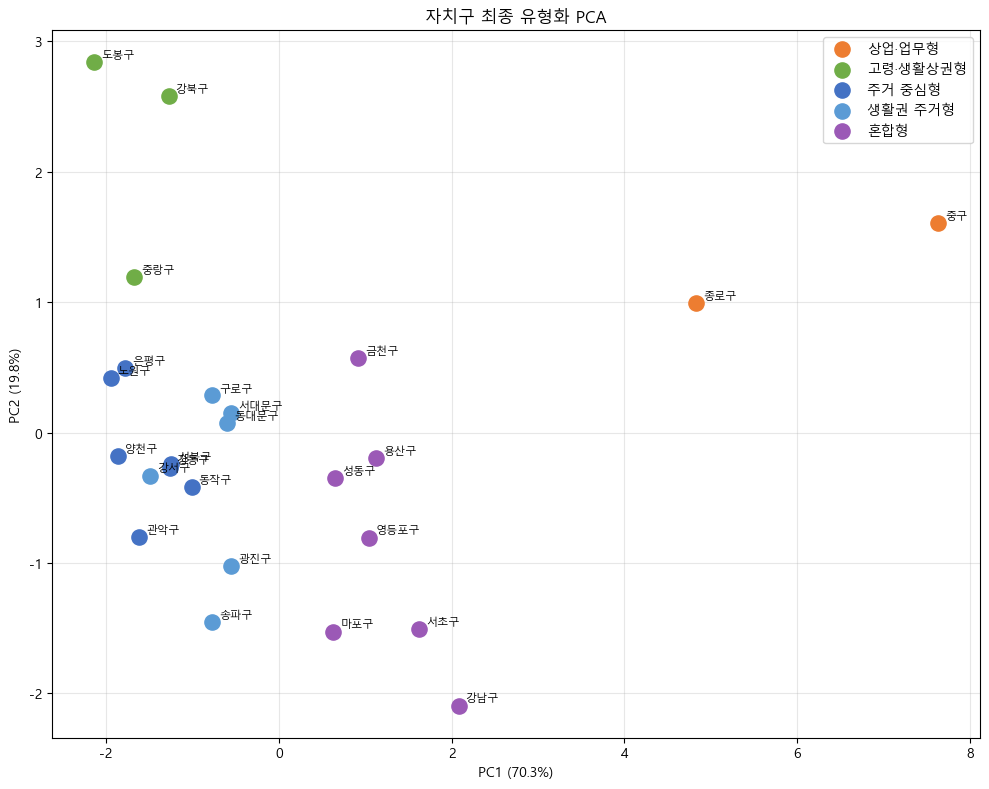


저장 완료: ..\..\data\final\cluster_pca_final_types.png


In [60]:
# ─────────────────────────────────────────────────────────
# 10-4. 최종 유형 PCA 시각화
# ─────────────────────────────────────────────────────────
from sklearn.decomposition import PCA

# X_scaled가 DataFrame일 수도 있고 ndarray일 수도 있으니 안전하게 처리
if isinstance(X_scaled, pd.DataFrame):
    X_for_pca = X_scaled.values
    gu_labels = X_scaled.index.tolist()
else:
    X_for_pca = X_scaled
    gu_labels = f['gu'].tolist()   # f의 행 순서가 X_scaled와 같다는 전제

# PCA
pca_final = PCA(n_components=2, random_state=42)
coords_final = pca_final.fit_transform(X_for_pca)

print(f"PC1 설명 분산: {pca_final.explained_variance_ratio_[0]:.1%}")
print(f"PC2 설명 분산: {pca_final.explained_variance_ratio_[1]:.1%}")

# 시각화용 데이터프레임
pca_plot_df = pd.DataFrame({
    'gu': gu_labels,
    'PC1': coords_final[:, 0],
    'PC2': coords_final[:, 1]
})

# f의 최종 유형 붙이기
pca_plot_df = pca_plot_df.merge(
    f[['gu', 'gu_type_final']],
    on='gu',
    how='left'
)

FINAL_COLORS = {
    '상업·업무형': '#ED7D31',
    '고령·생활상권형': '#70AD47',
    '주거 중심형': '#4472C4',
    '생활권 주거형': '#5B9BD5',
    '혼합형': '#9B59B6',
    '물류·혼합형': '#FFC000'
}

fig, ax = plt.subplots(figsize=(10, 8))

for t in final_type_order:
    tmp = pca_plot_df[pca_plot_df['gu_type_final'] == t]
    if len(tmp) == 0:
        continue

    ax.scatter(
        tmp['PC1'], tmp['PC2'],
        c=FINAL_COLORS.get(t, 'gray'),
        s=120,
        label=t,
        zorder=3
    )

# 자치구 라벨 표시
for _, row in pca_plot_df.iterrows():
    ax.annotate(
        row['gu'],
        (row['PC1'], row['PC2']),
        textcoords='offset points',
        xytext=(5, 3),
        fontsize=8
    )

ax.set_xlabel(f"PC1 ({pca_final.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca_final.explained_variance_ratio_[1]:.1%})")
ax.set_title("자치구 최종 유형화 PCA")
ax.legend(loc='best')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / 'cluster_pca_final_types.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n저장 완료:", OUT / 'cluster_pca_final_types.png')

레이더 차트 사용 변수:
['biz_per_10k', 'day_night_ratio', 'elderly_ratio', 'emp_per_pop', 'food_accom_ratio', 'living_pop_ratio', 'log_total_pop']

── 레이더 차트용 z-score 프로파일 ──


,주거성\n(인구·고령화),유동성\n(생활·주야간),상업성\n(사업체·종사자),음식숙박\n비중
gu_type_final,,,,
상업·업무형,-0.95,2.72,2.78,-1.52
고령·생활상권형,0.86,-0.73,-0.57,1.31
주거 중심형,0.29,-0.64,-0.63,0.56
생활권 주거형,0.09,-0.32,-0.33,0.22
혼합형,-0.46,0.45,0.36,-0.88


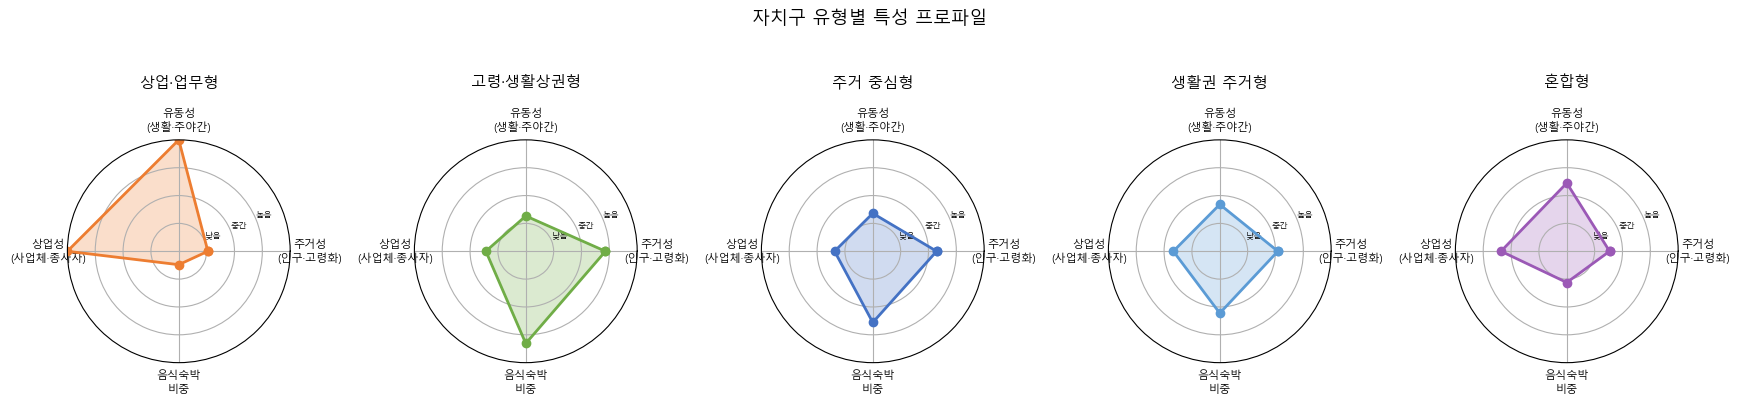


레이더 차트 저장 완료:
..\..\data\final\cluster_radar_final_types.png


In [ ]:
# ============================================================
# 10-5. 최종 유형 레이더 차트
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 레이더 축 4개
AXES = [
    "주거성\n(인구·고령화)",
    "유동성\n(생활·주야간)",
    "상업성\n(사업체·종사자)",
    "음식숙박\n비중"
]

AXIS_COLS = [
    ["log_total_pop", "elderly_ratio"],
    ["living_pop_ratio", "day_night_ratio"],
    ["biz_per_10k", "emp_per_pop"],
    ["food_accom_ratio"]
]


AXIS_COLS = [[c for c in cols if c in f.columns] for cols in AXIS_COLS]

# 레이더 차트에 사용할 변수 목록
radar_feature_cols = sorted(set(sum(AXIS_COLS, [])))

print("레이더 차트 사용 변수:")
print(radar_feature_cols)

# 최종 유형 순서
candidate_type_order = [
    '상업·업무형',
    '고령·생활상권형',
    '주거 중심형',
    '생활권 주거형',
    '혼합형',
    '물류·혼합형'
]

TYPE_ORDER = [t for t in candidate_type_order if t in f['gu_type_final'].unique()]

# 색상
FINAL_COLORS = {
    '상업·업무형': '#ED7D31',
    '고령·생활상권형': '#70AD47',
    '주거 중심형': '#4472C4',
    '생활권 주거형': '#5B9BD5',
    '혼합형': '#9B59B6',
    '물류·혼합형': '#FFC000'
}

# 전체 자치구 기준 z-score
z_df = f.copy()

z_df[radar_feature_cols] = (
    z_df[radar_feature_cols] - z_df[radar_feature_cols].mean()
) / z_df[radar_feature_cols].std()

# 최종 유형별 평균 z-score
cluster_z_final = (
    z_df
    .groupby("gu_type_final")[radar_feature_cols]
    .mean()
    .reindex(TYPE_ORDER)
)

# 군집별 각 축 평균 z-score 계산
radar_data = {}

for axis_name, cols in zip(AXES, AXIS_COLS):
    if len(cols) > 0:
        radar_data[axis_name] = cluster_z_final[cols].mean(axis=1)

radar_df = pd.DataFrame(radar_data).reindex(TYPE_ORDER)

print("\n── 레이더 차트용 z-score 프로파일 ──")
display(radar_df.round(2))

# 레이더 차트 그리기
n_axes = len(radar_df.columns)
angles = [2 * np.pi * i / n_axes for i in range(n_axes)]
angles += angles[:1]

fig, axes = plt.subplots(
    1,
    len(radar_df),
    figsize=(3.5 * len(radar_df), 3.8),
    subplot_kw=dict(polar=True)
)

if len(radar_df) == 1:
    axes = [axes]

for ax, (label, row) in zip(axes, radar_df.iterrows()):
    # z-score를 0~1 범위로 변환
    # -2 ~ +2 정도를 낮음~높음 범위로 표현
    vals = (row.values + 2) / 4
    vals = np.clip(vals, 0, 1)
    vals = np.append(vals, vals[0])

    color = FINAL_COLORS.get(label, "gray")

    ax.plot(angles, vals, "o-", linewidth=2, color=color)
    ax.fill(angles, vals, alpha=0.25, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_df.columns, fontsize=8)

    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(["낮음", "중간", "높음"], fontsize=6)

    ax.set_title(label, fontsize=11, pad=15)

plt.suptitle("자치구 유형별 특성 프로파일", fontsize=13, y=1.05)
plt.tight_layout()
plt.savefig(OUT / "cluster_radar_final_types.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n레이더 차트 저장 완료:")
print(OUT / "cluster_radar_final_types.png")

